#**ALGORITMOS ML**
--------------------------------------------------------------------------------
* **Marcos Cortizo Albiñana**

* **Raquel Pérez Roa**

En este proyecto se llevará a cabo el entrenamiento de diferentes modelos de clasificación binaria a partir del conjunto de datos ya preprocesado.

Inicialmente, el conjunto de entrenamiento se separará en dos subconjuntos: uno destinado al entrenamiento del modelo y otro a su validación. Con el objetivo de identificar la mejor configuración de hiperparámetros para cada clasificador, se utilizará Grid Search, una técnica que permite probar distintas combinaciones mediante validación cruzada y seleccionar aquella que obtenga el mejor rendimiento según la exactitud.

IMPORTACIÓN DE LIBRERÍAS y DATASET:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from IPython.display import Image
import pydotplus
from six import StringIO
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, RocCurveDisplay, classification_report
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

#Entrada de dataset preprocesado.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Proyecto Sistemas/datos_preprocesado_media_moda_sin_outliers.csv')
data

,FEV1_L,FVC_L,Ratio_FEV1_FVC,Flujo_Espiratorio_Max_L_min,Capacidad_Pulmonar_Total_L,Saturacion_O2_Reposo_porcentaje,Saturacion_O2_Esfuerzo_porcentaje,Nivel_Eosinofilos_cel_mcL,Distancia_Marcha_6min_m,Frecuencia_Respiratoria_rpm,Anios_Fumador,Exposicion_Biomasa,Riesgo_Exacerbacion
0,1.62,4.25,0.81,491.28,3.92,94.17,107.16,454.82,619.72,22.79,54.0,2.0,1
1,3.03,2.89,0.32,179.17,7.74,97.12,68.20,306.63,143.33,18.11,5.0,3.0,0
2,2.59,4.28,0.62,325.11,6.13,90.58,85.20,412.00,270.96,18.93,10.0,1.0,0
3,2.96,2.99,0.54,164.22,8.35,92.91,71.34,292.74,44.52,17.01,16.0,3.0,1
4,2.50,3.57,0.62,760.80,7.36,83.50,72.62,312.11,368.08,30.85,26.0,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2065,2.96,3.43,0.77,377.78,5.79,92.94,94.58,402.67,388.57,22.12,31.0,3.0,1
2066,2.05,3.01,1.10,130.82,7.12,90.97,119.12,424.10,375.19,3.45,8.0,3.0,0
2067,2.80,0.94,0.53,203.28,3.47,96.99,71.48,234.74,120.14,20.50,38.0,3.0,1
2068,2.55,1.23,0.62,281.69,6.51,95.31,102.40,431.33,502.10,10.95,58.0,1.0,0


##Preparación de dataframe de validación y entrenamiento:
Antes de entrenar los modelos, se prepara el conjunto de datos separando las variables predictoras de la variable objetivo. La variable objetivo será aquella que se desea predecir, en este caso Riesgo_Exacerbacion, mientras que el resto de columnas se emplearán como variables de entrada.

Además, el dataset se divide en dos subconjuntos: uno de entrenamiento y otro de validación. El conjunto de entrenamiento se utiliza para ajustar el modelo, mientras que el conjunto de validación permite evaluar su rendimiento con datos que el modelo no ha visto durante el entrenamiento.

In [ ]:
#variables de entrada
X_data = data.loc[:, data.columns != 'Riesgo_Exacerbacion'].copy()

#variable objetivo
Y_data = data['Riesgo_Exacerbacion'].copy()

X_data_train, X_data_val, Y_data_train, Y_data_val = train_test_split(X_data,Y_data,test_size=0.2,random_state=42,stratify=Y_data)

Con esta división, el 80% de los datos se usará para entrenar el modelo y el 20% restante para validarlo.

El parámetro stratify=Y_data sirve para mantener una proporción similar de pacientes con y sin riesgo de exacerbación tanto en entrenamiento como en validación.

Estandarizamos SVM, KNN y regresión logística porque son modelos sensibles a la escala de las variables y pueden verse dominados por columnas con valores numéricos más grandes.

No estandarizamos árbol de decisión ni Random Forest porque la escala no afecta a su funcionamiento y además se mantiene mejor la interpretación.


In [ ]:
sc = StandardScaler()

X_data_train_scaled = sc.fit_transform(X_data_train)
X_data_val_scaled = sc.transform(X_data_val)

##Árbol de decisión:

El árbol de decisión es un modelo de clasificación supervisada que representa el proceso de predicción mediante una estructura ramificada. El algoritmo va separando progresivamente los datos en grupos cada vez más similares entre sí, seleccionando en cada división la variable que permite diferenciar mejor las clases, mediante criterios como el índice de Gini o la ganancia de información.

Cada nodo del árbol contiene una condición aplicada a una característica del dataset, y según se cumpla o no dicha condición, los datos avanzan por una rama u otra. Este proceso continúa hasta alcanzar los nodos finales u hojas, donde se asigna la clase predicha. Una de sus principales ventajas es que resulta fácil de interpretar, ya que permite comprender de forma visual qué reglas sigue el modelo para tomar sus decisiones. Además, no necesita que los datos estén normalizados ni requiere asumir una distribución concreta de las variables.

**Cálculo de parámetros:**
Como el dataset utilizado está formado por variables numéricas previamente procesadas y el objetivo del estudio es resolver un problema de clasificación binaria, resulta apropiado emplear los criterios gini y entropy dentro del GridSearchCV aplicado al árbol de decisión.

Estos dos criterios permiten valorar la calidad de cada división realizada en los nodos del árbol y son los más habituales en este tipo de modelos. El criterio gini evalúa el grado de impureza de los grupos generados, mientras que entropy utiliza una medida basada en la cantidad de información aportada por cada partición.

Dado que el conjunto de datos está compuesto principalmente por variables clínicas numéricas y por alguna variable categórica ya codificada numéricamente, como Exposicion_Biomasa, resulta adecuado emplear un árbol de decisión para abordar este problema de clasificación binaria.



In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4]}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid,scoring='accuracy',cv=5)

grid_dt.fit(X_data_train, Y_data_train)

grid_dt.best_params_

{'criterion': 'entropy',
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 20}

In [ ]:
#creación y entrenamiento del clasificador
clf_dt = DecisionTreeClassifier(criterion='entropy',max_depth=5,min_samples_leaf=4,min_samples_split=20,random_state=42)
clf_dt.fit(X_data_train, Y_data_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=4,
                       min_samples_split=20, random_state=42)

Predicción sobre los datos de validación y matriz de confusión:

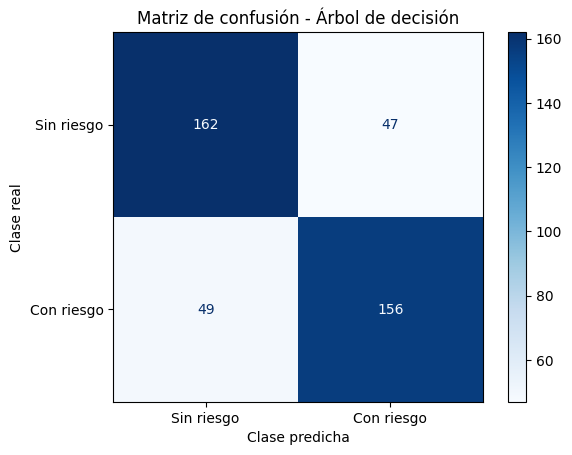

In [ ]:
Y_pred_dt = clf_dt.predict(X_data_val)
# cálculo de la matriz de confusión
matriz_dt = confusion_matrix(Y_data_val, Y_pred_dt)

# representación gráfica
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_dt,display_labels=['Sin riesgo', 'Con riesgo'])

disp.plot(cmap='Blues')
plt.title('Matriz de confusión - Árbol de decisión')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.show()

La matriz de confusión muestra un rendimiento medio del árbol de decisión, con bastantes aciertos en ambas clases, aunque todavía presenta una cantidad significativa de errores  tanto en falsos positivos como en falsos negativos.


In [ ]:
# Exactitud, precisión, sensibilidad y F1-score - Árbol de decisión


exactitud_dt = accuracy_score(Y_data_val, Y_pred_dt)
precision_dt = precision_score(Y_data_val, Y_pred_dt)
sensibilidad_dt = recall_score(Y_data_val, Y_pred_dt)
f1_dt = f1_score(Y_data_val, Y_pred_dt)

print("Métricas del árbol de decisión sobre los datos de validación:")
print("Exactitud:", exactitud_dt)
print("Precisión:", precision_dt)
print("Sensibilidad:", sensibilidad_dt)
print("F1-score:", f1_dt)

Métricas del árbol de decisión sobre los datos de validación:
Exactitud: 0.7681159420289855
Precisión: 0.7684729064039408
Sensibilidad: 0.7609756097560976
F1-score: 0.7647058823529411


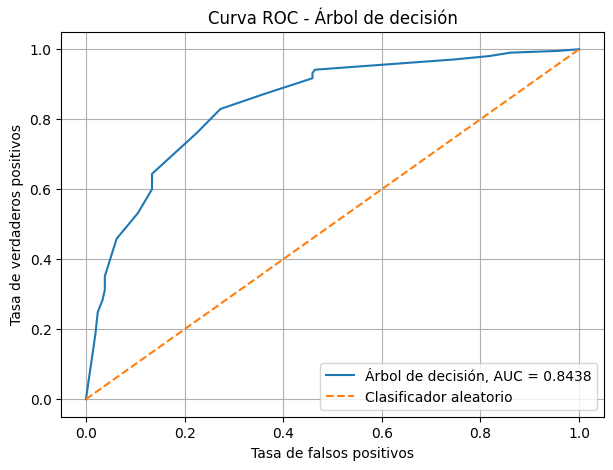

Área bajo la curva AUC: 0.8437623993464816


In [ ]:
# Curva ROC y área bajo la curva AUC

# probabilidad de pertenecer a la clase positiva
Y_prob_dt = clf_dt.predict_proba(X_data_val)[:, 1]

#  curva ROC
fpr_dt, tpr_dt, thresholds_dt = roc_curve(Y_data_val, Y_prob_dt)

# cálculo del área bajo la curva
auc_dt = auc(fpr_dt, tpr_dt)


plt.figure(figsize=(7, 5))
plt.plot(fpr_dt, tpr_dt, label=f'Árbol de decisión, AUC = {auc_dt:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Clasificador aleatorio')

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC - Árbol de decisión')
plt.legend()
plt.grid(True)
plt.show()

print("Área bajo la curva AUC:", auc_dt)

El árbol de decisión obtiene un rendimiento moderado sobre los datos de validación, con valores de exactitud, precisión, sensibilidad y F1-score cercanos al 76%. Esto indica que el modelo consigue clasificar correctamente una proporción de pacientes (sin acercarse a un gran resultado), manteniendo un equilibrio entre la detección de casos con riesgo y la fiabilidad de sus predicciones positivas. Además, el AUC de 0.8438 refleja una buena capacidad discriminativa entre pacientes con y sin riesgo de exacerbación. Sin embargo, al tratarse de un único árbol, sus resultados pueden estar limitados por cierta sensibilidad al sobreajuste o a divisiones concretas del dataset, por lo que será útil compararlo con modelos más robustos como Random Forest.


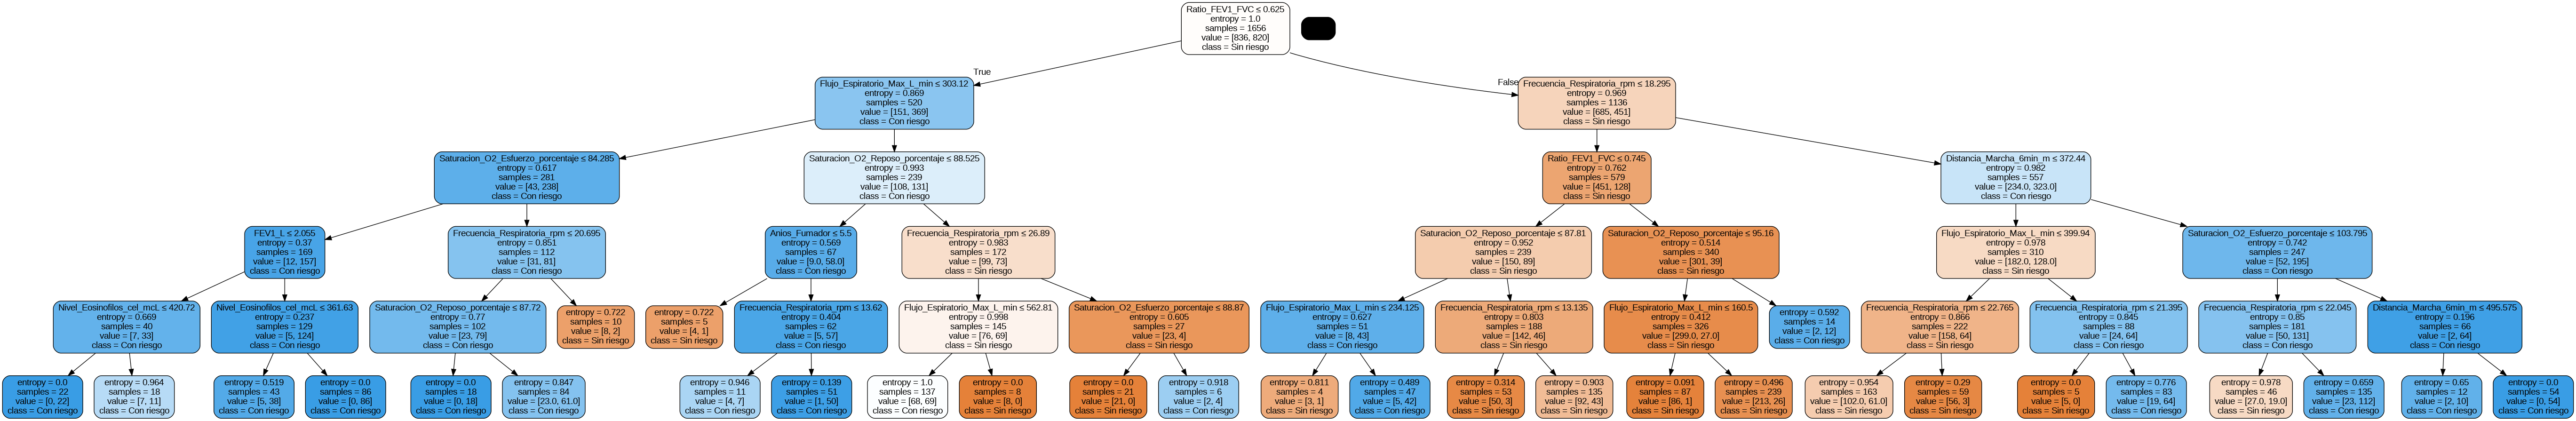

In [ ]:
# Nombres de las variables de entrada
nombres_columnas = X_data.columns.tolist()

# Creación del archivo DOT
dot_data = StringIO()

export_graphviz(clf_dt,out_file=dot_data,filled=True,rounded=True,special_characters=True,feature_names=nombres_columnas,class_names=['Sin riesgo', 'Con riesgo'])

# Conversión del árbol a imagen
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

En la visualización del árbol de decisión se observa que la primera variable utilizada para separar los pacientes es Ratio_FEV1_FVC, lo que indica que el modelo considera esta característica relevante para distinguir entre pacientes con y sin riesgo de exacerbación. A partir de esta primera división, el árbol continúa utilizando variables relacionadas con la función respiratoria, como Flujo_Espiratorio_Max_L_min, Frecuencia_Respiratoria_rpm, Saturacion_O2_Reposo_porcentaje, Saturacion_O2_Esfuerzo_porcentaje y Distancia_Marcha_6min_m. Esto sugiere que el modelo basa gran parte de sus decisiones en parámetros clínicos relacionados con la capacidad pulmonar, la oxigenación y la tolerancia al esfuerzo.

No obstante, debido a que el árbol tiene varias ramificaciones, no resulta adecuado interpretar cada nodo de forma aislada, ya que algunas divisiones dependen mucho de subconjuntos concretos de datos. Por ello, la principal utilidad de esta visualización es comprender de forma general qué variables intervienen antes en la clasificación y cómo se construyen las reglas de decisión.


Se ha comenzado con el árbol de decisión porque es un modelo sencillo e interpretable, que permite visualizar de manera clara las reglas utilizadas. Sin embargo, un único árbol puede ser sensible a pequeñas variaciones en los datos y presentar riesgo de sobreajuste. Por este motivo, a continuación se evaluará Random Forest.

##Random Forest:

Random Forest es un modelo de aprendizaje supervisado que utiliza varios árboles de decisión de forma conjunta. En lugar de basarse en un único árbol, construye diferentes árboles a partir de subconjuntos aleatorios de datos y variables. Cada árbol emite una predicción y, en problemas de clasificación, el resultado final se obtiene por clase mas votada. De esta forma, el modelo consigue ser más estable que un árbol individual, reduciendo el riesgo de sobreajuste y mejorando su capacidad para clasificar correctamente nuevos datos.

In [ ]:
param_grid = {'n_estimators': [50, 100, 200],'max_depth': [None, 10, 20, 30],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),param_grid=param_grid,scoring='accuracy',cv=5)

grid_rf.fit(X_data_train, Y_data_train)

grid_rf.best_params_

{'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}

In [ ]:
clf_rf = RandomForestClassifier(n_estimators=200,max_depth=20,min_samples_split=5,min_samples_leaf=1,random_state=42)

clf_rf.fit(X_data_train, Y_data_train)

RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=200,
                       random_state=42)

Predicción sobre los datos de validación y matriz de confusión:

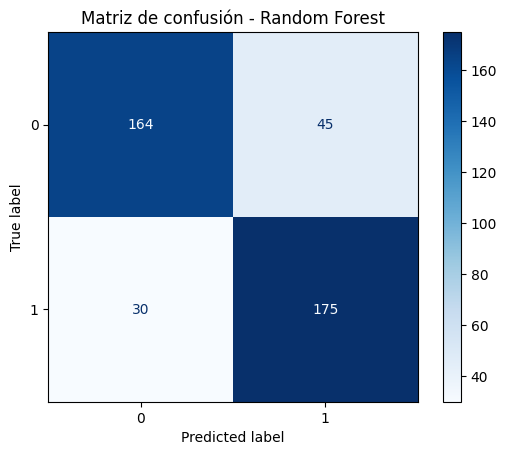

In [ ]:
Y_data_rf_pred = clf_rf.predict(X_data_val)
# Cálculo de la matriz de confusión
matriz_rf = confusion_matrix(Y_data_val, Y_data_rf_pred)

# Representación gráfica
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_rf,display_labels=clf_rf.classes_)

disp.plot(cmap='Blues')
plt.title("Matriz de confusión - Random Forest")
plt.show()



In [ ]:
# Exactitud, precisión, sensibilidad y F1-score - Árbol de decisión
exactitud_rf = accuracy_score(Y_data_val, Y_data_rf_pred)
precision_rf = precision_score(Y_data_val, Y_data_rf_pred)
sensibilidad_rf = recall_score(Y_data_val, Y_data_rf_pred)
f1_rf = f1_score(Y_data_val, Y_data_rf_pred)

print("Métricas Random Forest")
print("----------------------")
print("Exactitud:", round(exactitud_rf, 4))
print("Precisión:", round(precision_rf, 4))
print("Sensibilidad:", round(sensibilidad_rf, 4))
print("F1-score:", round(f1_rf, 4))

Métricas Random Forest
----------------------
Exactitud: 0.8188
Precisión: 0.7955
Sensibilidad: 0.8537
F1-score: 0.8235


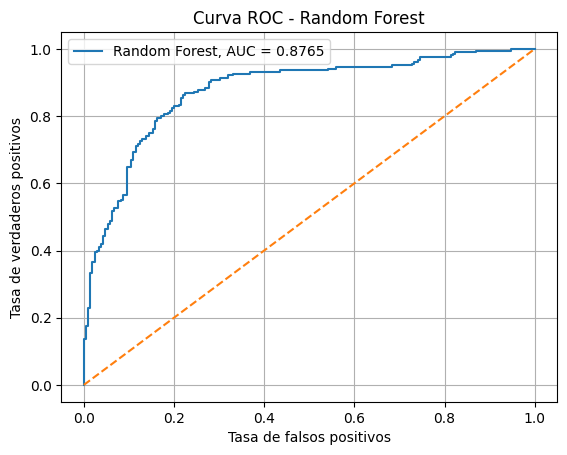

AUC Random Forest: 0.8765


In [ ]:

# Probabilidad de pertenecer a la clase positiva
Y_data_rf_prob = clf_rf.predict_proba(X_data_val)[:, 1]

# Curva ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(Y_data_val, Y_data_rf_prob)

# Área bajo la curva
auc_rf = auc(fpr_rf, tpr_rf)

# Representación gráfica
plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest, AUC = {auc_rf:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.grid()
plt.show()

print("AUC Random Forest:", round(auc_rf, 4))

El modelo Random Forest ha obtenido un rendimiento bastante bueno sobre los datos de validación. La exactitud alcanzada es de 0.8188, lo que indica que el modelo clasifica correctamente aproximadamente el 81,88% de los casos.

A partir de la matriz de confusión se observa que el modelo clasifica correctamente 164 pacientes sin riesgo y 175 pacientes con riesgo de exacerbación. Sin embargo, comete 45 falsos positivos y 30 falsos negativos.

La sensibilidad obtenida es de 0.8537, lo que significa que el modelo identifica correctamente una proporción elevada de los pacientes que realmente presentan riesgo de exacerbación.

La precisión es de 0.7955, por lo que, de todos los pacientes que el modelo clasifica como positivos, alrededor del 79,55% realmente presentan riesgo. Además, el F1-score es de 0.8235, lo que refleja un buen equilibrio entre precisión y sensibilidad.

Por último, la curva ROC muestra un AUC de 0.8765, valor cercano a 1, lo que indica que el modelo tiene una buena capacidad para distinguir entre pacientes con y sin riesgo de exacerbación.

Finalmente, se pude decir que Random Forest presenta un comportamiento equilibrado, con buena capacidad predictiva y una sensibilidad elevada. Aunque todavía existen algunos errores de clasificación, especialmente falsos positivos.

## Algoritmo SVM
El algoritmo de Máquinas de Vectores de Soporte, conocido como SVM, es un método de clasificación supervisada cuyo objetivo es encontrar la frontera de decisión que mejor separa las clases. Esta frontera recibe el nombre de hiperplano y se elige de forma que el margen entre los puntos más cercanos de cada clase sea lo más amplio posible. Estos puntos cercanos son los llamados vectores de soporte.

SVM resulta especialmente útil cuando los datos no pueden separarse fácilmente de forma lineal, ya que permite emplear funciones kernel para transformar el espacio original de las variables y facilitar la separación entre clases. Una de sus implementaciones más habituales es SVC, que permite seleccionar distintos tipos de kernel y ajustar hiperparámetros como C y gamma.

En este modelo se utilizará el dataset escalado, ya que SVM es sensible a la escala de las variables.

Cálculo de la mejor combinación de parámetros para SVM

Para optimizar el modelo SVM se utilizará GridSearchCV, probando distintas combinaciones de hiperparámetros. En este caso, se consideran principalmente kernels no lineales, como rbf y sigmoid, ya que permiten modelar relaciones más complejas entre las variables clínicas y la variable objetivo.

El kernel rbf es especialmente adecuado cuando las clases no se separan mediante una línea recta, ya que puede generar fronteras de decisión curvas y adaptarse mejor a patrones no lineales. Por su parte, el kernel sigmoid también permite capturar relaciones no lineales, aunque su comportamiento puede depender más de la configuración de los parámetros.

In [ ]:
param_grid_svm = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.1, 0.01, 0.001, 0.0001, 0.00001],
    'kernel': ['rbf', 'sigmoid']}

grid_svm = GridSearchCV(SVC(),param_grid=param_grid_svm,scoring='accuracy',cv=5,n_jobs=-1)

grid_svm.fit(X_data_train_scaled, Y_data_train)

print("Mejores parámetros:", grid_svm.best_params_)

Mejores parámetros: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


In [ ]:
#creación, entrenamiento y predición de clasificador
clf_svm_data = SVC(random_state=42,C=100, gamma=0.01,kernel='rbf',probability=True)

clf_svm_data.fit(X_data_train_scaled, Y_data_train)

Y_data_svm_pred = clf_svm_data.predict(X_data_val_scaled)


Datos de validación y matriz de confusión

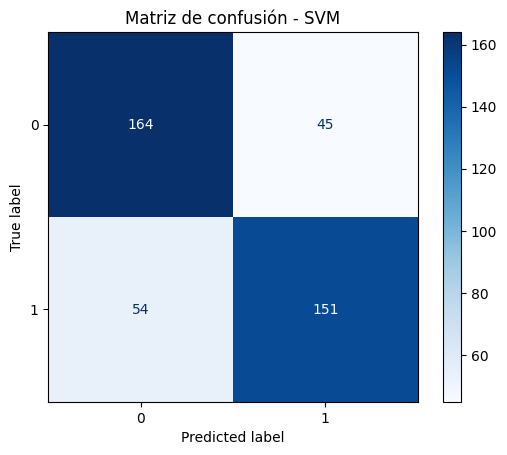

In [ ]:
# Matriz de confusión
matriz_svm = confusion_matrix(Y_data_val, Y_data_svm_pred)

# Representación gráfica
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_svm,
    display_labels=clf_svm_data.classes_
)

disp.plot(cmap='Blues')
plt.title("Matriz de confusión - SVM")
plt.show()

In [ ]:
exactitud_svm = accuracy_score(Y_data_val, Y_data_svm_pred)
precision_svm = precision_score(Y_data_val, Y_data_svm_pred)
sensibilidad_svm = recall_score(Y_data_val, Y_data_svm_pred)
f1_svm = f1_score(Y_data_val, Y_data_svm_pred)

print("Métricas SVM")
print("------------")
print("Exactitud:", round(exactitud_svm, 4))
print("Precisión:", round(precision_svm, 4))
print("Sensibilidad:", round(sensibilidad_svm, 4))
print("F1-score:", round(f1_svm, 4))

Métricas SVM
------------
Exactitud: 0.7609
Precisión: 0.7704
Sensibilidad: 0.7366
F1-score: 0.7531


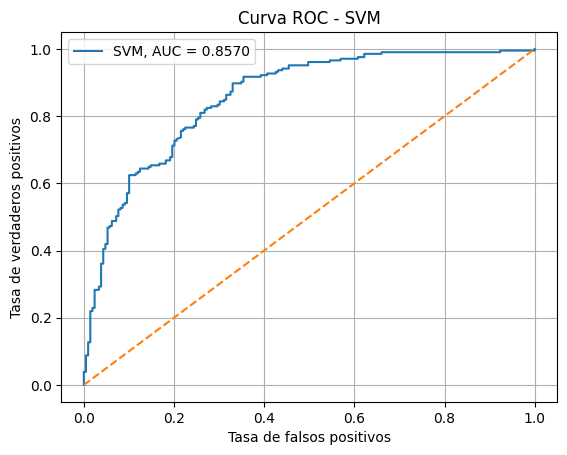

AUC SVM: 0.857


In [ ]:
# Probabilidad de pertenecer a la clase positiva
Y_data_svm_prob = clf_svm_data.predict_proba(X_data_val_scaled)[:, 1]

# Curva ROC
fpr_svm, tpr_svm, thresholds_svm = roc_curve(Y_data_val, Y_data_svm_prob)

# Área bajo la curva
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure()
plt.plot(fpr_svm, tpr_svm, label=f"SVM, AUC = {auc_svm:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - SVM")
plt.legend()
plt.grid()
plt.show()

print("AUC SVM:", round(auc_svm, 4))

El modelo SVM obtiene una exactitud del 76,09%, lo que indica que clasifica correctamente aproximadamente tres de cada cuatro pacientes del conjunto de validación.
A partir de la matriz de confusión, se observa que el modelo identifica correctamente 164 pacientes sin riesgo y 151 pacientes con riesgo. Sin embargo, comete 45 falsos positivos y 54 falsos negativos.
La precisión de 0,7704 indica que, cuando el modelo predice riesgo de exacerbación, acierta en torno al 77% de los casos. Por otro lado, la sensibilidad de 0,7366 muestra que detecta aproximadamente el 73,66% de los pacientes que realmente presentan riesgo.

El F1-score de 0,7531 refleja un equilibrio razonable entre precisión y sensibilidad. Además, el valor de AUC = 0,857 indica que el modelo tiene una buena capacidad para distinguir entre pacientes con y sin riesgo de exacerbación.

En conjunto, SVM presenta un comportamiento moderado, especialmente según la curva ROC, aunque todavía muestra margen de mejora en la detección de pacientes con riesgo, ya que los falsos negativos son relativamente relevantes.

## Clasificación KNN
El algoritmo K-Nearest Neighbors (KNN) es un método de clasificación supervisada que asigna una clase a una nueva muestra según las clases de sus vecinos más cercanos. Para ello, calcula la distancia entre la muestra que se quiere clasificar y los datos de entrenamiento, selecciona los k vecinos más próximos y asigna la clase más frecuente entre ellos.
En este caso se utilizará el dataset escalado, ya que KNN se basa en el cálculo de distancias y, si las variables tienen rangos muy diferentes, aquellas con valores más grandes podrían influir demasiado en la clasificación.

Búsqueda del número óptimo de vecinos

El rendimiento de KNN depende en gran medida del valor de k, es decir, del número de vecinos considerados. Por ello, se probarán distintos valores de k, entrenando el modelo con los datos escalados y evaluando su exactitud sobre el conjunto de validación.

Mejor número de vecinos (k): 43
Mejor exactitud en validación: 0.7826


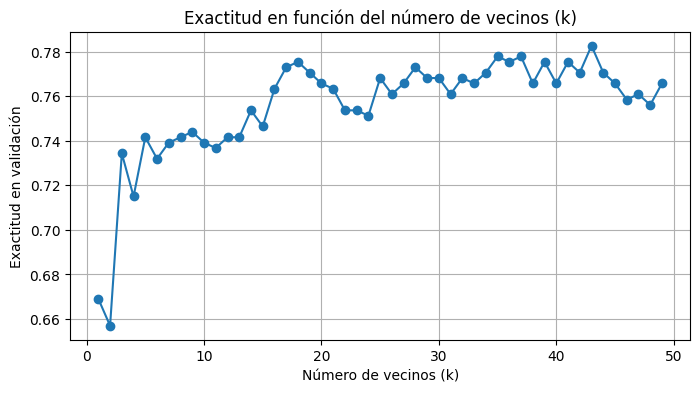

In [ ]:
accuracies_knn = []

# Valores de k
valores_k = range(1, 50)

#probar distintos valores de k
for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_data_train_scaled, Y_data_train)
    Y_data_knn_pred = knn.predict(X_data_val_scaled)
    acc = accuracy_score(Y_data_val, Y_data_knn_pred)
    accuracies_knn.append(acc)


best_k = valores_k[accuracies_knn.index(max(accuracies_knn))]

print(f"Mejor número de vecinos (k): {best_k}")
print(f"Mejor exactitud en validación: {max(accuracies_knn):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(valores_k, accuracies_knn, marker='o')

plt.title('Exactitud en función del número de vecinos (k)')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Exactitud en validación')
plt.grid(True)

plt.show()

Una vez obtenido el mejor valor de vecinos, k = 43, con una exactitud de 0.7826, se realiza una búsqueda adicional de hiperparámetros para optimizar el comportamiento del modelo KNN.

Aunque el número de vecinos es uno de los parámetros más importantes, también influyen otros aspectos como el tipo de ponderación de los vecinos y la métrica de distancia utilizada. Por ello, se emplea GridSearchCV para probar las opciones más habituales: uniform y distance para los pesos, y euclidean y manhattan como métricas de distancia.

In [ ]:
param_grid_knn = {
    'n_neighbors': [43],  # Mejor valor de k obtenido previamente
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']}

grid_knn = GridSearchCV(KNeighborsClassifier(),param_grid=param_grid_knn,scoring='accuracy',cv=5)


grid_knn.fit(X_data_train_scaled, Y_data_train)


print("Mejores parámetros:", grid_knn.best_params_)
print("Mejor exactitud en validación cruzada:", round(grid_knn.best_score_, 4))

Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 43, 'weights': 'distance'}
Mejor exactitud en validación cruzada: 0.776


In [ ]:
clf_knn = KNeighborsClassifier(n_neighbors=43,weights='distance',metric='manhattan')

clf_knn.fit(X_data_train_scaled, Y_data_train)

# Predicción sobre validación escalada
Y_data_knn_pred = clf_knn.predict(X_data_val_scaled)

Datos de validación y matriz de confusión

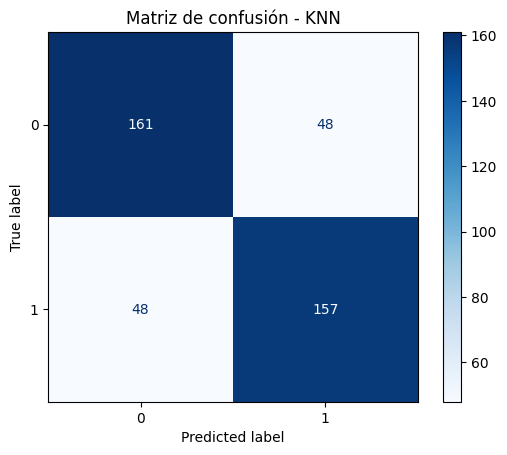

In [ ]:
matriz_knn = confusion_matrix(Y_data_val, Y_data_knn_pred)

# matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_knn,display_labels=clf_knn.classes_)

disp.plot(cmap='Blues')
plt.title("Matriz de confusión - KNN")
plt.show()

In [ ]:
#métricas en validación
exactitud_knn = accuracy_score(Y_data_val, Y_data_knn_pred)
precision_knn = precision_score(Y_data_val, Y_data_knn_pred)
sensibilidad_knn = recall_score(Y_data_val, Y_data_knn_pred)
f1_knn = f1_score(Y_data_val, Y_data_knn_pred)

print("Métricas KNN")
print("------------")
print("Exactitud:", round(exactitud_knn, 4))
print("Precisión:", round(precision_knn, 4))
print("Sensibilidad:", round(sensibilidad_knn, 4))
print("F1-score:", round(f1_knn, 4))

Métricas KNN
------------
Exactitud: 0.7681
Precisión: 0.7659
Sensibilidad: 0.7659
F1-score: 0.7659


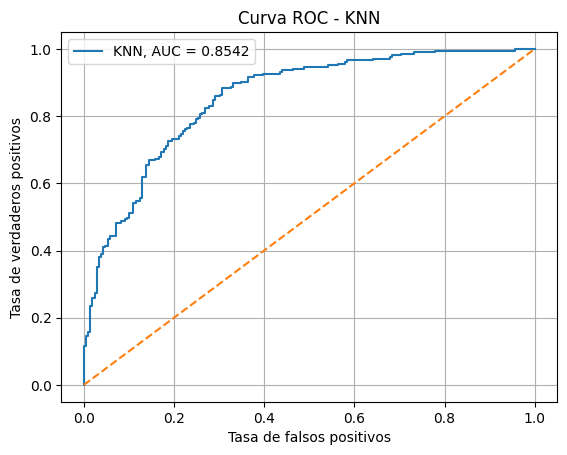

AUC KNN: 0.8542


In [ ]:
# Probabilidad de pertenecer a clase positiva
Y_data_knn_prob = clf_knn.predict_proba(X_data_val_scaled)[:, 1]

# Cálculo de puntos de curva ROC
fpr_knn, tpr_knn, thresholds_knn = roc_curve(Y_data_val, Y_data_knn_prob)

# Cálculo del área bajo curva
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure()
plt.plot(fpr_knn, tpr_knn, label=f"KNN, AUC = {auc_knn:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - KNN")
plt.legend()
plt.grid()
plt.show()

print("AUC KNN:", round(auc_knn, 4))

La exactitud obtenida es de 0.7681, lo que indica que el modelo clasifica correctamente aproximadamente el 76,8% de los casos.

La matriz de confusión muestra un comportamiento bastante equilibrado entre ambas clases, ya que el modelo acierta 161 casos sin riesgo y 157 casos con riesgo, pero también comete 48 falsos positivos y 48 falsos negativos. Esto indica que el clasificador no está claramente sesgado hacia una de las dos clases.

Además, la precisión, la sensibilidad y el F1-score presentan valores muy similares, alrededor de 0.7659, lo que refuerza la idea de que el modelo mantiene un equilibrio entre detectar correctamente los pacientes con riesgo y evitar clasificaciones positivas incorrectas.

Por último, el valor de AUC = 0.8542 indica que el modelo tiene una buena capacidad para distinguir entre pacientes con y sin riesgo de exacerbación. Aunque la exactitud no es extremadamente alta, la curva ROC muestra que KNN separa razonablemente bien ambas clases

## Regresión logística
La regresión logística tiene como objetivo estimar la probabilidad de que una muestra pertenezca a una clase determinada, en este caso, si existe o no riesgo de exacerbación.

El modelo combina las variables de entrada de forma lineal y transforma el resultado mediante una función sigmoide, obteniendo una probabilidad entre 0 y 1. Si esta probabilidad supera un umbral, normalmente 0.5, la muestra se clasifica como clase positiva.

En este caso se utilizará el dataset escalado, ya que la regresión logística puede verse afectada por diferencias de escala entre las variables clínicas.

In [ ]:
# Creación del clasificador de regresión logística
clf_rlog = LogisticRegression(random_state=42)

# Entrenamiento con los datos escalados
clf_rlog.fit(X_data_train_scaled, Y_data_train)


LogisticRegression(random_state=42)

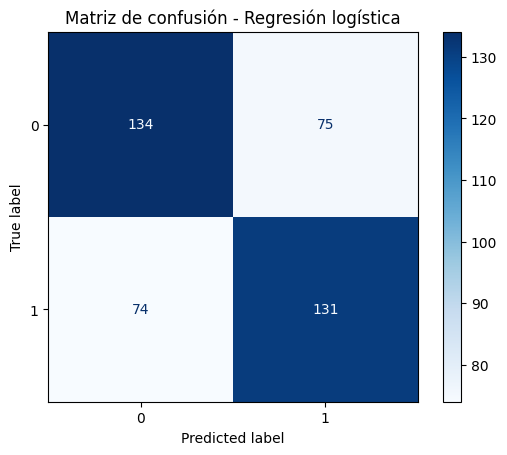

In [ ]:
Y_data_rlog_pred = clf_rlog.predict(X_data_val_scaled)

# Cálculo de la matriz de confusión
matriz_rlog = confusion_matrix(Y_data_val, Y_data_rlog_pred)

# Representación gráfica de la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_rlog,display_labels=clf_rlog.classes_)

disp.plot(cmap='Blues')
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [ ]:
exactitud_rlog = accuracy_score(Y_data_val, Y_data_rlog_pred)
precision_rlog = precision_score(Y_data_val, Y_data_rlog_pred)
sensibilidad_rlog = recall_score(Y_data_val, Y_data_rlog_pred)
f1_rlog = f1_score(Y_data_val, Y_data_rlog_pred)


print("Métricas Regresión Logística")
print("----------------------------")
print("Exactitud:", round(exactitud_rlog, 4))
print("Precisión:", round(precision_rlog, 4))
print("Sensibilidad:", round(sensibilidad_rlog, 4))
print("F1-score:", round(f1_rlog, 4))

Métricas Regresión Logística
----------------------------
Exactitud: 0.6401
Precisión: 0.6359
Sensibilidad: 0.639
F1-score: 0.6375


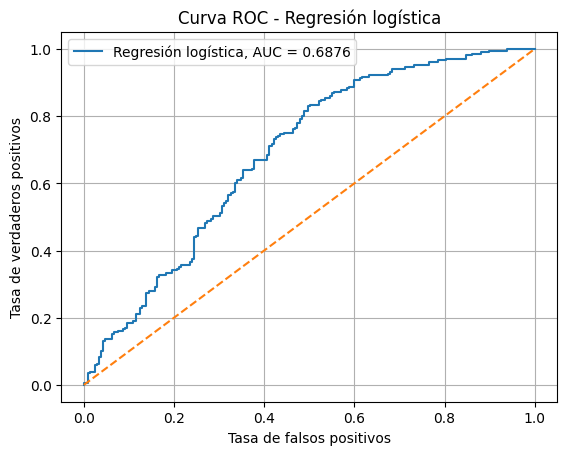

AUC Regresión Logística: 0.6876


In [ ]:
Y_data_rlog_prob = clf_rlog.predict_proba(X_data_val_scaled)[:, 1]

# Cálculo de los puntos de la curva ROC
fpr_rlog, tpr_rlog, thresholds_rlog = roc_curve(Y_data_val, Y_data_rlog_prob)

# Cálculo del área bajo la curva
auc_rlog = auc(fpr_rlog, tpr_rlog)

# Representación gráfica de la curva ROC
plt.figure()
plt.plot(fpr_rlog, tpr_rlog, label=f"Regresión logística, AUC = {auc_rlog:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Regresión logística")
plt.legend()
plt.grid()
plt.show()

print("AUC Regresión Logística:", round(auc_rlog, 4))

La regresión logística obtiene un rendimiento malo, con una exactitud de 0.6401, prácticamente acierta lo mismo que falla.
Es decir, indica que clasifica correctamente aproximadamente el 64% de los casos de validación. La precisión es de 0.6359, la sensibilidad de 0.6390 y el F1-score de 0.6375, valores bastante similares entre sí. Esto muestra que el modelo tiene un comportamiento limitado.

En la matriz de confusión se observa que el modelo acierta 134 casos sin riesgo de exacerbación y 131 casos con riesgo de exacerbación. Sin embargo, también comete un número elevado de errores, con 75 falsos positivos y 74 falsos negativos. Esto indica que el modelo confunde ambas clases con bastante frecuencia.
El valor de AUC = 0.6876 refleja que la regresión logística tiene poca capacidad para diferenciar entre pacientes con y sin riesgo de exacerbación.

## Análisis de resultados y conclusión


Tras entrenar y evaluar los cinco modelos sobre el conjunto de validación, se observa que aunque todos los modelos, salvo la regresión logística, presentan cierta capacidad para clasificar a los pacientes, el rendimiento no es igual en todos los casos.

In [ ]:
resultados_modelos = pd.DataFrame([
    {"Modelo": "Árbol de decisión", "Exactitud": "≈ 0.76", "Precisión": "≈ 0.76", "Sensibilidad": "≈ 0.76", "F1-score": "≈ 0.76", "AUC": "0.8438"},
    {"Modelo": "Random Forest", "Exactitud": "0.8188", "Precisión": "0.7955", "Sensibilidad": "0.8537", "F1-score": "0.8235", "AUC": "0.8765"},
    {"Modelo": "SVM", "Exactitud": "0.7609", "Precisión": "0.7704", "Sensibilidad": "0.7366", "F1-score": "0.7531", "AUC": "0.8570"},
    {"Modelo": "KNN", "Exactitud": "0.7681", "Precisión": "≈ 0.7659", "Sensibilidad": "≈ 0.7659", "F1-score": "≈ 0.7659", "AUC": "0.8542"},
    {"Modelo": "Regresión logística", "Exactitud": "0.6401", "Precisión": "0.6359", "Sensibilidad": "0.6390", "F1-score": "0.6375", "AUC": "0.6876"}
])

print("Comparación de métricas de los modelos")

display(resultados_modelos)

Comparación de métricas de los modelos


,Modelo,Exactitud,Precisión,Sensibilidad,F1-score,AUC
0,Árbol de decisión,≈ 0.76,≈ 0.76,≈ 0.76,≈ 0.76,0.8438
1,Random Forest,0.8188,0.7955,0.8537,0.8235,0.8765
2,SVM,0.7609,0.7704,0.7366,0.7531,0.8570
3,KNN,0.7681,≈ 0.7659,≈ 0.7659,≈ 0.7659,0.8542
4,Regresión logística,0.6401,0.6359,0.6390,0.6375,0.6876


El árbol de decisión obtiene un rendimiento moderado. Su principal ventaja es la interpretabilidad, pero sus métricas no destacan frente al resto.

KNN y SVM presentan resultados parecidos. Ambos tienen una exactitud cercana al 76% y un AUC superior a 0.85. Esto indica que son capaces de separar razonablemente bien ambas clases. Sin embargo, ninguno de los dos alcanza el equilibrio conseguido por Random Forest. SVM presenta más falsos negativos, algo poco deseable en un problema donde interesa detectar pacientes con riesgo.

La regresión logística es claramente el modelo más débil. Sus métricas son bastante inferiores y el AUC de 0.6876 muestra una capacidad discriminativa limitada. El modelo confunde con frecuencia ambas clases, por lo que no resulta adecuado para este problema. Su bajo rendimiento sugiere que la relación entre las variables clínicas y el riesgo de exacerbación no se ajusta bien a una frontera lineal simple.

El modelo con mejor rendimiento global es Random Forest. Obtiene la mayor exactitud, el mayor F1-score y el mayor AUC. Además, presenta la sensibilidad más alta entre los modelos principales, lo que significa que detecta mejor a los pacientes que realmente presentan riesgo de exacerbación.

Por tanto, se selecciona Random Forest como el algoritmo más adecuado para este dataset. No es un modelo perfecto, ya que sigue cometiendo falsos positivos y falsos negativos, pero ofrece el mejor equilibrio entre capacidad predictiva, sensibilidad y robustez. Además, al combinar varios árboles de decisión, reduce parte de la inestabilidad propia de un árbol individual y proporciona un comportamiento más fiable sobre los datos de validación.


##Guardado del algoritmo elegido
Una vez seleccionado el modelo final, se guarda el clasificador entrenado para poder utilizarlo posteriormente sin necesidad de volver a entrenarlo. En este caso, al tratarse de un modelo Random Forest, no es necesario guardar el escalador, ya que este algoritmo no depende de la escala de las variables.

In [ ]:
# Guardado del modelo Random Forest elegido
joblib.dump(clf_rf,'/content/drive/MyDrive/Proyecto Sistemas/random_forest_media_moda_sin_outliers.pkl')

['/content/drive/MyDrive/Proyecto Sistemas/random_forest_media_moda_sin_outliers.pkl']